<a href="https://colab.research.google.com/github/Khushibung05/RAG/blob/main/Embedding2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

Task 1: Load Embedding Model


In [2]:
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"

model = SentenceTransformer(model_name)

print("Model Name:", model_name)

sample_embedding = model.encode("Test sentence")

print("Embedding Dimension:", len(sample_embedding))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384


Task 2: Generate Embeddings

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

chunk_embeddings = model.encode(chunks)

for chunk, emb in zip(chunks, chunk_embeddings):
    print("\nChunk:")
    print(chunk)

    print("Embedding Shape:")
    print(emb.shape)

    print("-"*50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Chunk:
Employees receive 12 casual leaves annually.
Embedding Shape:
(384,)
--------------------------------------------------

Chunk:
Employees receive 15 sick leaves annually.
Embedding Shape:
(384,)
--------------------------------------------------

Chunk:
Employees may work from home twice per week.
Embedding Shape:
(384,)
--------------------------------------------------

Chunk:
Travel expenses are reimbursed within 30 days.
Embedding Shape:
(384,)
--------------------------------------------------

Chunk:
All employees are covered under company medical insurance.
Embedding Shape:
(384,)
--------------------------------------------------


Task 3: Analyze Embedding Vectors

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

text = "Employees receive 12 casual leaves annually."

embedding = model.encode(text)

print("First 20 Values:\n")

print(embedding[:20])
print("""
ANALYSIS

Embeddings contain decimal values because they are learned numerical
representations produced by a neural network.

Each value captures a hidden semantic feature of the text.

The entire vector together represents the meaning of the sentence.
""")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

First 20 Values:

[ 0.06183616  0.01376684  0.03366627  0.01861072  0.03135883  0.06788085
 -0.01135738 -0.01733116 -0.07070485  0.01901562  0.10987661  0.05092816
 -0.04896781 -0.04620623 -0.03665629  0.00247606 -0.06287517  0.00541345
  0.03131732 -0.0771486 ]

ANALYSIS

Embeddings contain decimal values because they are learned numerical
representations produced by a neural network.

Each value captures a hidden semantic feature of the text.

The entire vector together represents the meaning of the sentence.



Task 4: Generate Query Embeddings

In [5]:
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

query_embeddings = model.encode(queries)

for query, emb in zip(queries, query_embeddings):

    print("\nQuery:")
    print(query)

    print("Embedding Shape:")
    print(emb.shape)

    print("-"*50)


Query:
How many casual leaves are allowed?
Embedding Shape:
(384,)
--------------------------------------------------

Query:
Can employees work remotely?
Embedding Shape:
(384,)
--------------------------------------------------

Query:
What is the travel reimbursement process?
Embedding Shape:
(384,)
--------------------------------------------------

Query:
Do employees have medical insurance?
Embedding Shape:
(384,)
--------------------------------------------------


Task 5: Semantic Similarity Analysis

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

for query, query_emb in zip(queries, query_embeddings):

    print("\n")
    print("="*60)
    print("Query:", query)
    print("="*60)

    similarities = cosine_similarity(
        [query_emb],
        chunk_embeddings
    )[0]

    for chunk, score in zip(chunks, similarities):

        print("\nChunk:")
        print(chunk)

        print("Similarity Score:",
              round(score,4))



Query: How many casual leaves are allowed?

Chunk:
Employees receive 12 casual leaves annually.
Similarity Score: 0.6552

Chunk:
Employees receive 15 sick leaves annually.
Similarity Score: 0.411

Chunk:
Employees may work from home twice per week.
Similarity Score: 0.1763

Chunk:
Travel expenses are reimbursed within 30 days.
Similarity Score: 0.0493

Chunk:
All employees are covered under company medical insurance.
Similarity Score: 0.0472


Query: Can employees work remotely?

Chunk:
Employees receive 12 casual leaves annually.
Similarity Score: 0.1963

Chunk:
Employees receive 15 sick leaves annually.
Similarity Score: 0.23

Chunk:
Employees may work from home twice per week.
Similarity Score: 0.4834

Chunk:
Travel expenses are reimbursed within 30 days.
Similarity Score: -0.0254

Chunk:
All employees are covered under company medical insurance.
Similarity Score: 0.3006


Query: What is the travel reimbursement process?

Chunk:
Employees receive 12 casual leaves annually.
Similar

Task 6: Identify Most Similar Chunk

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

for query, query_emb in zip(queries, query_embeddings):

    similarities = cosine_similarity(
        [query_emb],
        chunk_embeddings
    )[0]

    best_idx = np.argmax(similarities)

    print("\nQuery:")
    print(query)

    print("\nMost Similar Chunk:")
    print(chunks[best_idx])

    print("\nSimilarity Score:")
    print(round(similarities[best_idx],4))

    print("-"*60)


Query:
How many casual leaves are allowed?

Most Similar Chunk:
Employees receive 12 casual leaves annually.

Similarity Score:
0.6552
------------------------------------------------------------

Query:
Can employees work remotely?

Most Similar Chunk:
Employees may work from home twice per week.

Similarity Score:
0.4834
------------------------------------------------------------

Query:
What is the travel reimbursement process?

Most Similar Chunk:
Travel expenses are reimbursed within 30 days.

Similarity Score:
0.7255
------------------------------------------------------------

Query:
Do employees have medical insurance?

Most Similar Chunk:
All employees are covered under company medical insurance.

Similarity Score:
0.803
------------------------------------------------------------


Task 7: Similar Meaning vs Different Meaning

Sentence Pair 1

Employees receive 12 casual leaves.
Workers are entitled to 12 annual leaves.

Sentence Pair 2

Employees receive 12 casual leaves.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

pair1 = [
    "Employees receive 12 casual leaves.",
    "Workers are entitled to 12 annual leaves."
]

pair2 = [
    "Employees receive 12 casual leaves.",
    "Travel expenses are reimbursed within 30 days."
]

emb1 = model.encode(pair1)
emb2 = model.encode(pair2)

similarity1 = cosine_similarity(
    [emb1[0]],
    [emb1[1]]
)[0][0]

similarity2 = cosine_similarity(
    [emb2[0]],
    [emb2[1]]
)[0][0]

print("Pair 1 Similarity:")
print(round(similarity1,4))

print("\nPair 2 Similarity:")
print(round(similarity2,4))
print("""
ANALYSIS

Pair 1 has higher similarity because both sentences discuss
employee leave benefits.

Although the wording is different, the meaning is almost identical.

Pair 2 discusses completely different topics:
leave policy vs travel reimbursement.

Therefore the similarity score is much lower.
""")

Pair 1 Similarity:
0.771

Pair 2 Similarity:
0.175

ANALYSIS

Pair 1 has higher similarity because both sentences discuss
employee leave benefits.

Although the wording is different, the meaning is almost identical.

Pair 2 discusses completely different topics:
leave policy vs travel reimbursement.

Therefore the similarity score is much lower.



Task 8: Embedding Visualization

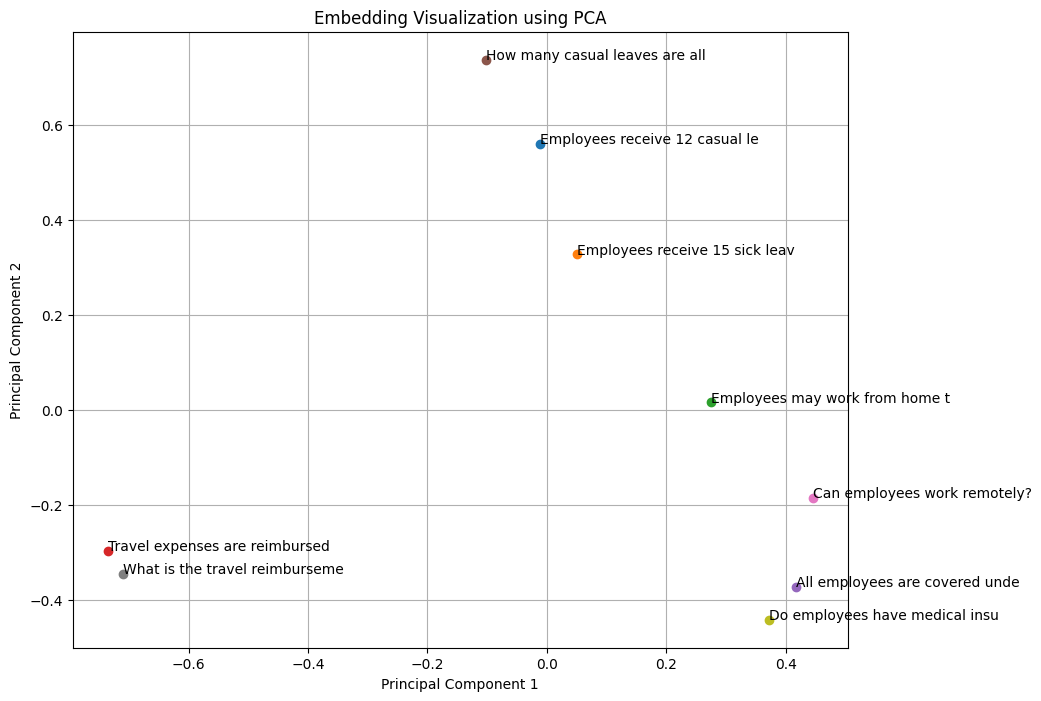

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

all_texts = chunks + queries

all_embeddings = model.encode(all_texts)

pca = PCA(n_components=2)

reduced = pca.fit_transform(all_embeddings)

plt.figure(figsize=(10,8))

for i, text in enumerate(all_texts):

    x = reduced[i,0]
    y = reduced[i,1]

    plt.scatter(x,y)

    plt.annotate(
        text[:30],
        (x,y)
    )

plt.title("Embedding Visualization using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [10]:
print("""
ANALYSIS

Semantically similar texts appear closer together because
their embeddings occupy nearby positions in vector space.

Examples:

'How many casual leaves are allowed?'

and

'Employees receive 12 casual leaves annually.'

should appear near each other.

Texts discussing unrelated topics appear farther apart.
""")


ANALYSIS

Semantically similar texts appear closer together because
their embeddings occupy nearby positions in vector space.

Examples:

'How many casual leaves are allowed?'

and

'Employees receive 12 casual leaves annually.'

should appear near each other.

Texts discussing unrelated topics appear farther apart.

